# 5 · Choropleth, shapes & map decoration

`choropleth` / `shapes` for vector polygons, plus coastlines / borders / basemap / named domains. Network-dependent overlays are wrapped so the notebook always renders.

In [1]:
%matplotlib inline
from pathlib import Path

# Resolve the repo root so the bundled sample data is found whether this runs
# from docs/examples/ (mkdocs) or the repository root.
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "acc4000.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RASTER = str(ROOT / "examples" / "data" / "acc4000.tif")
POINTS = str(ROOT / "tests" / "data" / "points.geojson")
print("data root:", ROOT)

data root: C:\gdrive\algorithms\Visualization\Digital-Earth


In [2]:
from pyramids.feature import FeatureCollection
from digitalearth.scene import Map

fc = FeatureCollection.read_file(POINTS)
polys = fc.copy()
polys['geometry'] = fc.geometry.buffer(800.0)  # points -> polygons

2026-05-28 00:31:00 | INFO | pyramids.base.config | Logging is configured.


## choropleth — polygons coloured by a column

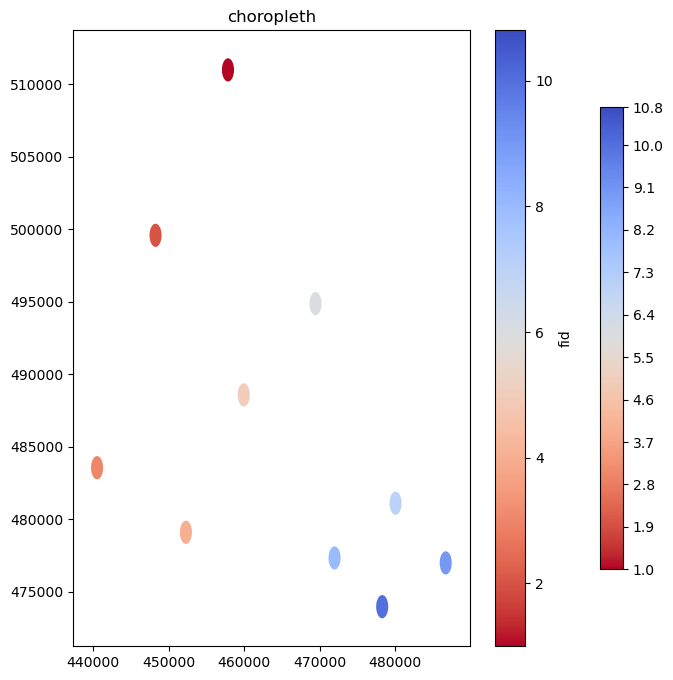

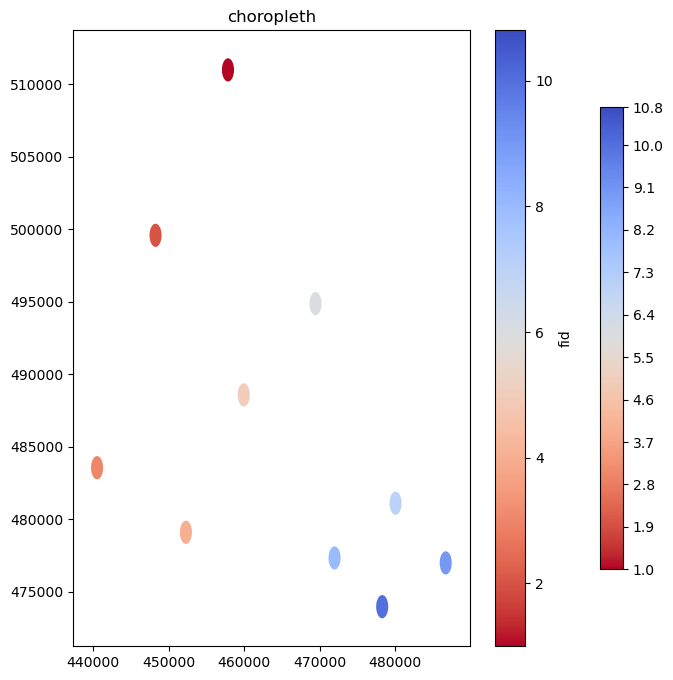

In [3]:
m = Map(crs=polys.epsg)
m.choropleth(polys, column='fid')
m.colorbar(label='fid')
m.set_title('choropleth')
m.fig

## shapes — outlines only

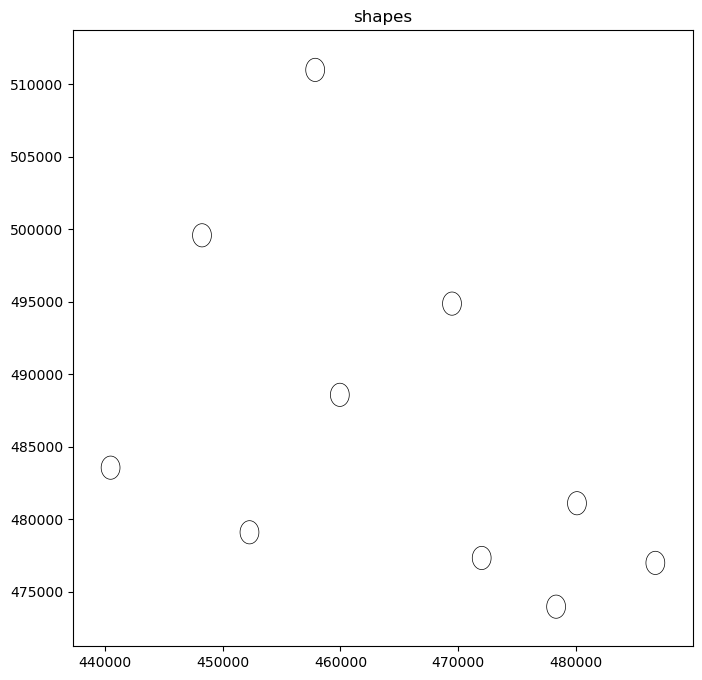

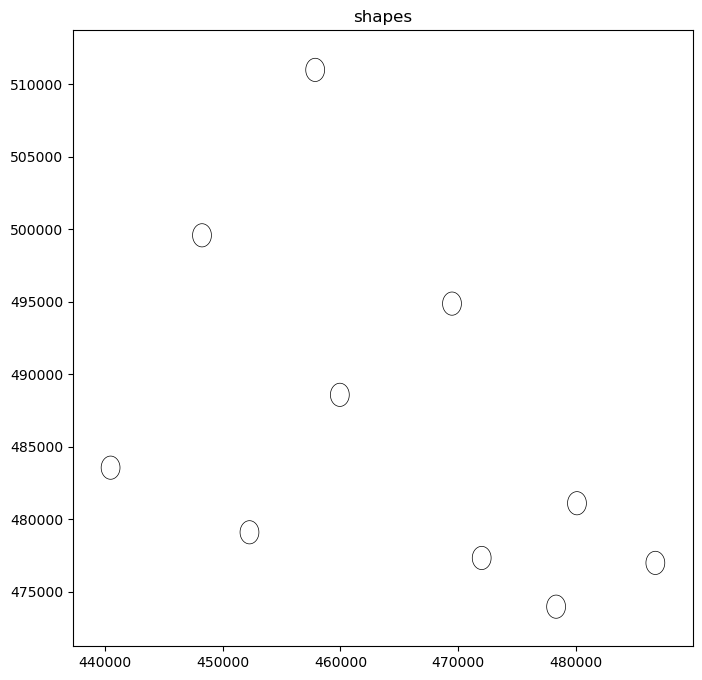

In [4]:
m = Map(crs=polys.epsg)
m.shapes(polys, edgecolor='black')
m.set_title('shapes')
m.fig

## Named domains (extent from a region, reprojected via pyramids)

xlim: [-2782987, 5009377]


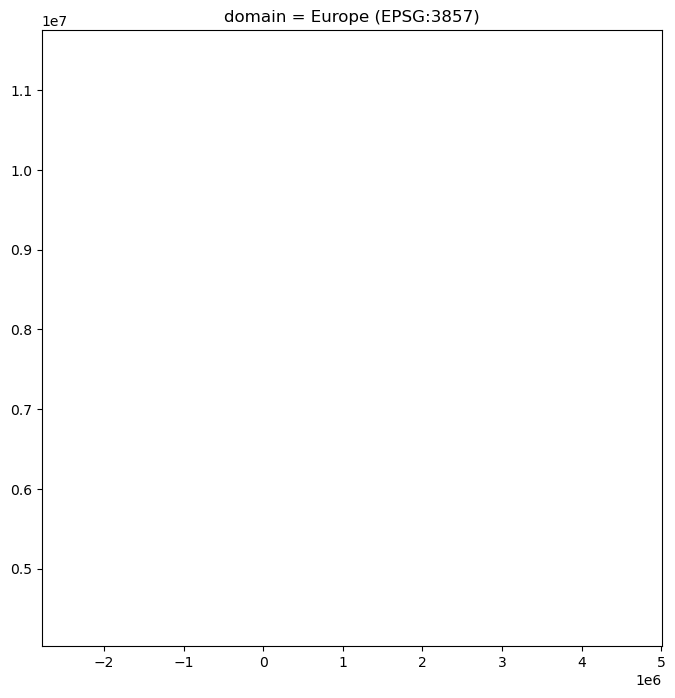

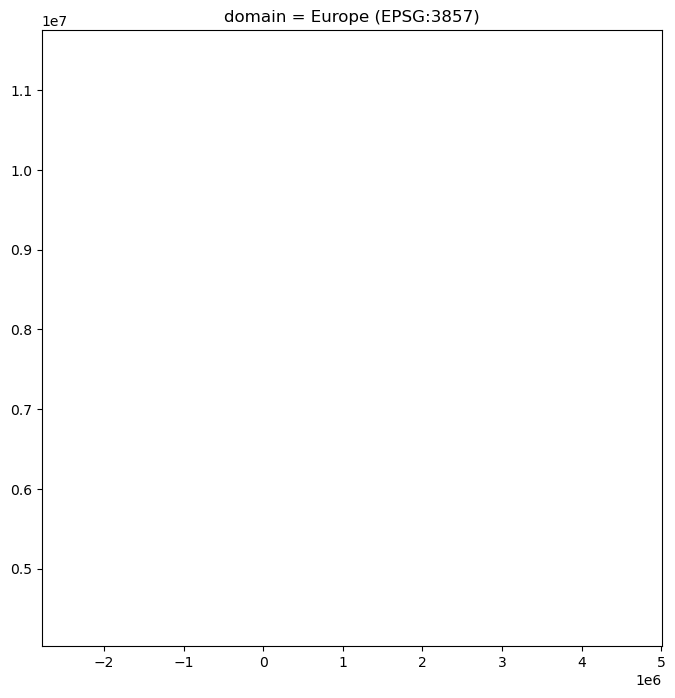

In [5]:
m = Map(crs=3857)
m.set_domain('europe')
print('xlim:', [round(float(v)) for v in m.ax.get_xlim()])
m.set_title('domain = Europe (EPSG:3857)')
m.fig

## Coastlines & basemap (need network — guarded)

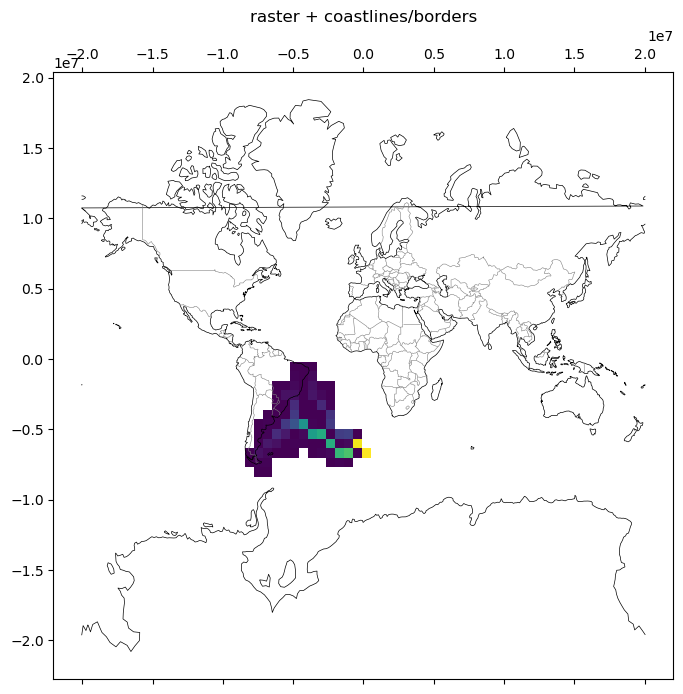

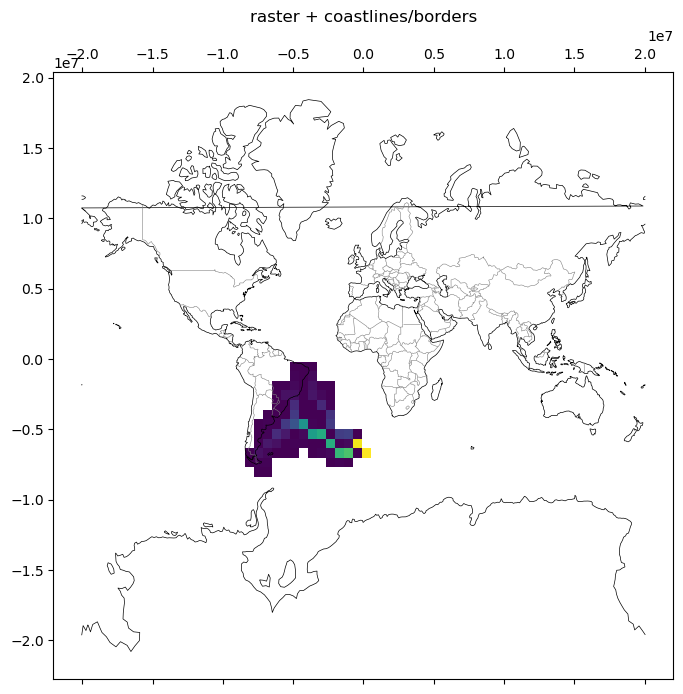

In [6]:
import numpy as np
from pyramids.dataset import Dataset
ds = Dataset.read_file(RASTER)
m = Map(crs=3857)
m.imshow(ds)
for name in ('coastlines', 'borders'):
    try:
        getattr(m, name)()
    except Exception as exc:
        print(f'{name}: unavailable offline ({type(exc).__name__})')
m.set_title('raster + coastlines/borders')
m.fig